### Importando bibliotecas


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns

### Criando tabelas

In [74]:

patients = pd.read_csv('hosp/patients.csv') # 100 pacientes
icu_stays = pd.read_csv('icu/icustays.csv') # Todos os 100 ficaram na UTI
input_events = pd.read_csv('icu/inputevents.csv') # 2 Não receberam medicamentos
procedure_events = pd.read_csv('icu/procedureevents.csv') # 2 Não receberam procedimentos
output_events = pd.read_csv('icu/outputevents.csv')
ingredient_events = pd.read_csv('icu/ingredientevents.csv')
items = pd.read_csv('icu/d_items.csv') # Itens e seus códigos

print("Nº de pacientes:", patients.shape[0])

Nº de pacientes: 100


### Contagem de eventos

#### Vasopressores (unidades de medida bem diferentes, talvez compense mais usar o número total de eventos?)

In [75]:
vasopressores = ['Vasopressin',
                 'Dopamine',
                 'Epinephrine',
                 'Norepinephrine',
                 'Phenylephrine',
                 'Milrinone',
                 'Dobutamine']


vp = items[items['label'].isin(vasopressores)]

vp = pd.merge(input_events,vp)
vasopres = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='event_count')
vasopres['stay_total_amount'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
vasopres['stay_mean'] = vp.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].mean().values
vasopres

,subject_id,stay_id,itemid,label,amountuom,event_count,stay_total_amount,stay_mean
0,10002428,35479615,221906,Norepinephrine,mg,31,13.224821,0.426607
1,10002428,38875437,221662,Dopamine,mg,11,196.758289,17.887117
2,10002428,38875437,221749,Phenylephrine,mg,7,54.767366,7.823909
3,10002428,38875437,221906,Norepinephrine,mg,9,0.671676,0.074631
4,10002495,36753294,221662,Dopamine,mg,3,53.395216,17.798405
...,...,...,...,...,...,...,...,...
85,10039708,33281088,221906,Norepinephrine,mg,174,264.498800,1.520108
86,10039708,33281088,222315,Vasopressin,units,9,327.040000,36.337778
87,10039708,38559363,221906,Norepinephrine,mg,5,2.249693,0.449939
88,10040025,36107367,221749,Phenylephrine,mg,13,52.036688,4.002822


#### Contagem de eventos de ventilação (talvez dê pra usar a duração em minutos??)

In [76]:
ventilacao = ['Mask Ventilation (Intubation)',
              'Non-invasive Ventilation',
              'Invasive Ventilation']

vt = items[items['label'].isin(ventilacao)]
vt = pd.merge(procedure_events,vt)
vent = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='event_count')
vent['total_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values
vent['average_duration'] = vt.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].mean().values
vent

,subject_id,stay_id,itemid,label,valueuom,event_count,total_duration,average_duration
0,10002428,34807493,225794,Non-invasive Ventilation,min,1,1809.0,1809.000000
1,10002428,35479615,225792,Invasive Ventilation,min,1,12640.0,12640.000000
2,10002428,38875437,225792,Invasive Ventilation,min,1,4135.0,4135.000000
3,10002495,36753294,225794,Non-invasive Ventilation,min,1,321.0,321.000000
4,10003400,32128372,225792,Invasive Ventilation,min,1,3760.0,3760.000000
...,...,...,...,...,...,...,...,...
63,10038933,32166508,225792,Invasive Ventilation,min,1,1453.0,1453.000000
64,10038992,37127068,225792,Invasive Ventilation,min,1,390.0,390.000000
65,10038999,39711498,225792,Invasive Ventilation,min,1,9621.0,9621.000000
66,10039708,33281088,225792,Invasive Ventilation,min,3,6650.0,2216.666667


#### Contagem de eventos de Terapia de Substituição Renal

In [77]:
tsr_ids = [ 226118,
            227357,
            225725,
            226499,
            224154,
            225810,
            225959,
            227639,
            225183,
            227438,
            224191,
            225806,
            225807,
            228004,
            228005,
            228006,
            224144,
            224145,
            224149,
            224150,
            224151,
            224152,
            224153,
            224404,
            224406,
            226457,
            224135,
            224139,
            224146,
            225323,
            225740,
            225776,
            225951,
            225952,
            225953,
            225954,
            225956,
            225958,
            225961,
            225963,
            225965,
            225976,
            225977,
            227124,
            227290,
            227638,
            227640,
            227753,
            227536,
            227525,
            225441,
            225802,
            225803,
            225805,
            225809,
            225955,
            224270,
            225436
]



vtsr = items[items['itemid'].isin(tsr_ids)]

##### Eventos de entrada (Também tem unidades de medida diferentes)

In [78]:
vtsri = pd.merge(input_events,vtsr)
tsri = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['itemid'].count().reset_index(name='count')
tsri['stay_total_amount'] = vtsri.groupby(['subject_id','stay_id','itemid','label','amountuom'])['amount'].sum().values
tsri

,subject_id,stay_id,itemid,label,amountuom,count,stay_total_amount
0,10004235,34100191,227525,Calcium Gluconate (CRRT),grams,9,62.996110
1,10004235,34100191,227536,KCl (CRRT),mEq.,21,162.394674
2,10007818,32359580,227525,Calcium Gluconate (CRRT),grams,20,194.071824
3,10007818,32359580,227536,KCl (CRRT),mEq.,33,245.243769
4,10035631,30932571,227525,Calcium Gluconate (CRRT),grams,22,225.171767
5,10039708,33281088,227525,Calcium Gluconate (CRRT),grams,18,166.606406
6,10039708,33281088,227536,KCl (CRRT),mEq.,51,421.719093


##### Eventos de procedimento (unidades diferentes, mas todas são de tempo)

In [79]:

vtsrp = pd.merge(procedure_events,vtsr)
tsrp = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['itemid'].count().reset_index(name='count')
tsrp['stay_total_duration'] = vtsrp.groupby(['subject_id','stay_id','itemid','label','valueuom'])['value'].sum().values


# Corrigindo as medidas de tempo
tsrp.loc[tsrp['valueuom'] == 'day', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='day']['stay_total_duration'] * 1440
tsrp.loc[tsrp['valueuom'] == 'hour', 'stay_total_duration']  = tsrp[tsrp['valueuom']=='hour']['stay_total_duration'] * 60
tsrp['valueuom'] = 'min'
tsrp
#tsrp[tsrp['']]

,subject_id,stay_id,itemid,label,valueuom,count,stay_total_duration
0,10004235,34100191,224270,Dialysis Catheter,min,1,5261.000000
1,10004235,34100191,225802,Dialysis - CRRT,min,1,2367.000000
2,10007818,32359580,224270,Dialysis Catheter,min,3,26363.000000
3,10007818,32359580,225441,Hemodialysis,min,1,210.000000
4,10007818,32359580,225441,Hemodialysis,min,2,453.000000
5,10007818,32359580,225802,Dialysis - CRRT,min,1,2370.000000
6,10007818,32359580,225802,Dialysis - CRRT,min,3,5217.000000
7,10010471,32119961,224270,Dialysis Catheter,min,1,707.000000
8,10010471,32119961,225441,Hemodialysis,min,1,131.000000
9,10021938,33083787,225441,Hemodialysis,min,1,1883.000000


##### Criando tabelona com todos os dados

In [80]:

tabelona = patients[['subject_id','gender','anchor_age','dod']].copy()


# Vasopressores
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vasopres['label'].unique():
        count = vasopres[(vasopres['subject_id'] == id) & (vasopres['label'] == v)]['event_count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'vasopressor_input_count'] = total_count

# Ventilação
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in vent['label'].unique():
        count = 0
        count =  vent[(vent['subject_id'] == id) & (vent['label'] == v)]['total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'ventilation_time (min)'] = total_count

# Procedimentos de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsrp['label'].unique():
        count = 0
        count =  tsrp[(tsrp['subject_id'] == id) & (tsrp['label'] == v)]['stay_total_duration'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_event_time (min)'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_event_time (min)'] = total_count

# Entrada de tsr
for id in tabelona['subject_id'].unique():
    total_count = 0
    for v in tsri['label'].unique():
        count = tsri[(tsri['subject_id'] == id) & (tsri['label'] == v)]['count'].sum()
        tabelona.loc[tabelona['subject_id'] == id, v + '_input_count'] = count
        total_count += count
    tabelona.loc[tabelona['subject_id'] == id, 'tsr_input_count'] = total_count

# Transformando sexo em booleano
tabelona['gender'] = tabelona['gender'] == 'F'

# Determinando as colunas de morte
tabelona['dod'] = pd.to_datetime(tabelona['dod'])
tabelona['death'] = ~tabelona['dod'].isna()

stays = pd.read_csv('icu/icustays.csv')[['outtime','subject_id']]
stays['outtime'] = pd.to_datetime(stays['outtime'])

stays_ultimo = stays.sort_values(by=["subject_id","outtime"],ascending=True)

stays_ultimo = stays_ultimo.groupby("subject_id").last().reset_index()

tabelona = pd.merge(tabelona,stays.groupby('subject_id')['outtime'].max().reset_index(name='last_outtime'))

for id in tabelona['subject_id']:
    tabelona.loc[tabelona['subject_id'] == id, 'icu_death'] = (tabelona[tabelona['subject_id'] ==id]['dod'].notnull()) & (tabelona[tabelona['subject_id'] ==id]['dod'] <= tabelona[tabelona['subject_id'] ==id]['last_outtime'] )


tabelona[['subject_id','anchor_age','gender','death','icu_death','dod','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)']]

mortos2 = tabelona[tabelona["icu_death"]==True]

mortos_id = mortos2["subject_id"].reset_index()

tabelona


,subject_id,gender,anchor_age,dod,Norepinephrine_input_count,Dopamine_input_count,Phenylephrine_input_count,Vasopressin_input_count,Epinephrine_input_count,Dobutamine_input_count,...,Dialysis Catheter_event_time (min),Dialysis - CRRT_event_time (min),Hemodialysis_event_time (min),tsr_event_time (min),Calcium Gluconate (CRRT)_input_count,KCl (CRRT)_input_count,tsr_input_count,death,last_outtime,icu_death
0,10014729,True,21,NaT,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2125-03-01 21:21:37,False
1,10003400,True,72,2137-09-02,30.0,0.0,88.0,14.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,2137-09-02 19:17:11,True
2,10002428,True,80,NaT,40.0,11.0,7.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2156-05-22 14:16:46,False
3,10032725,True,38,2143-03-30,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,2143-03-25 15:05:33,False
4,10027445,True,48,2146-02-09,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True,2142-08-31 18:19:36,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,10004733,False,51,NaT,14.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2174-12-12 20:03:01,False
96,10021118,False,62,NaT,0.0,0.0,11.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2161-11-20 21:45:42,False
97,10018501,False,83,NaT,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2141-08-01 22:36:21,False
98,10007058,False,48,NaT,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,2167-11-09 20:55:04,False


#### Checando a distribuição dos dados

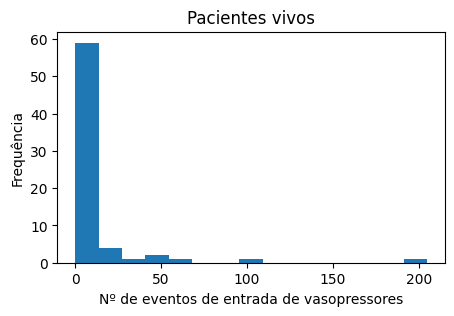

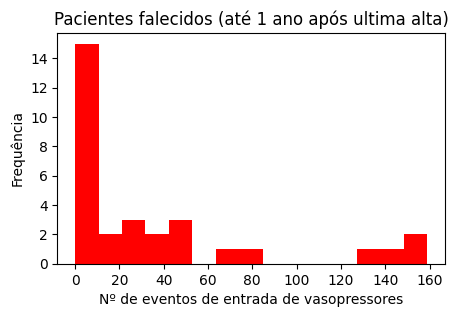

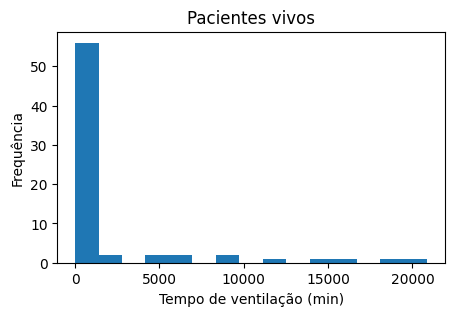

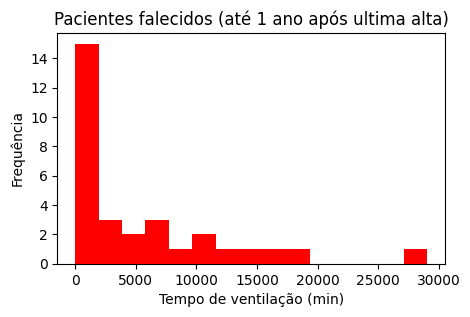

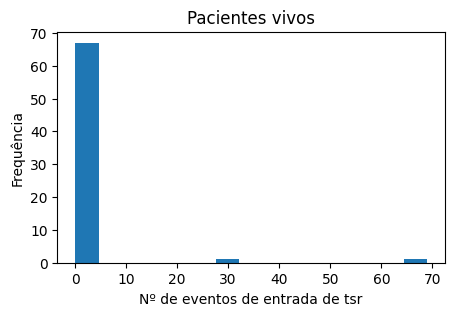

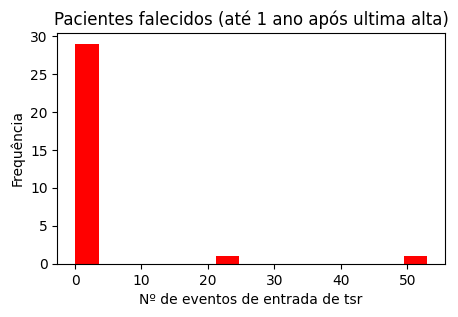

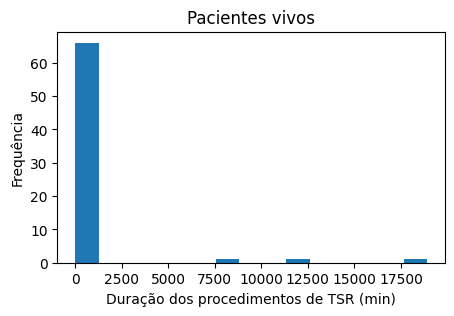

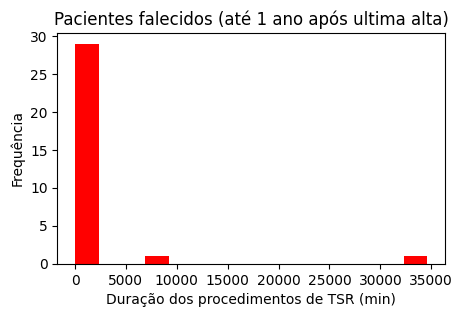

In [81]:

vivos = tabelona[tabelona['dod'].isna()]
mortos = tabelona[~tabelona['dod'].isna()]

# VASOPRESSORES
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(vivos['vasopressor_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de vasopressores")
plt.hist(mortos['vasopressor_input_count'],bins=15,color='red')
plt.show()

# VENTILAÇÃO
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(vivos['ventilation_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Tempo de ventilação (min)")
plt.hist(mortos['ventilation_time (min)'],bins=15,color='red')
plt.show()

# ENTRADA DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(vivos['tsr_input_count'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Nº de eventos de entrada de tsr")
plt.hist(mortos['tsr_input_count'],bins=15,color='red')
plt.show()

# PROCEDIMENTOS DE TSR
plt.figure(figsize=[5,3])
plt.title("Pacientes vivos")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(vivos['tsr_event_time (min)'],bins=15)
plt.show()
plt.figure(figsize=[5,3])
plt.title("Pacientes falecidos (até 1 ano após ultima alta)")
plt.ylabel("Frequência")
plt.xlabel("Duração dos procedimentos de TSR (min)")
plt.hist(mortos['tsr_event_time (min)'],bins=15,color='red')
plt.show()

#### Pairplot para identificar alguma correlação visual

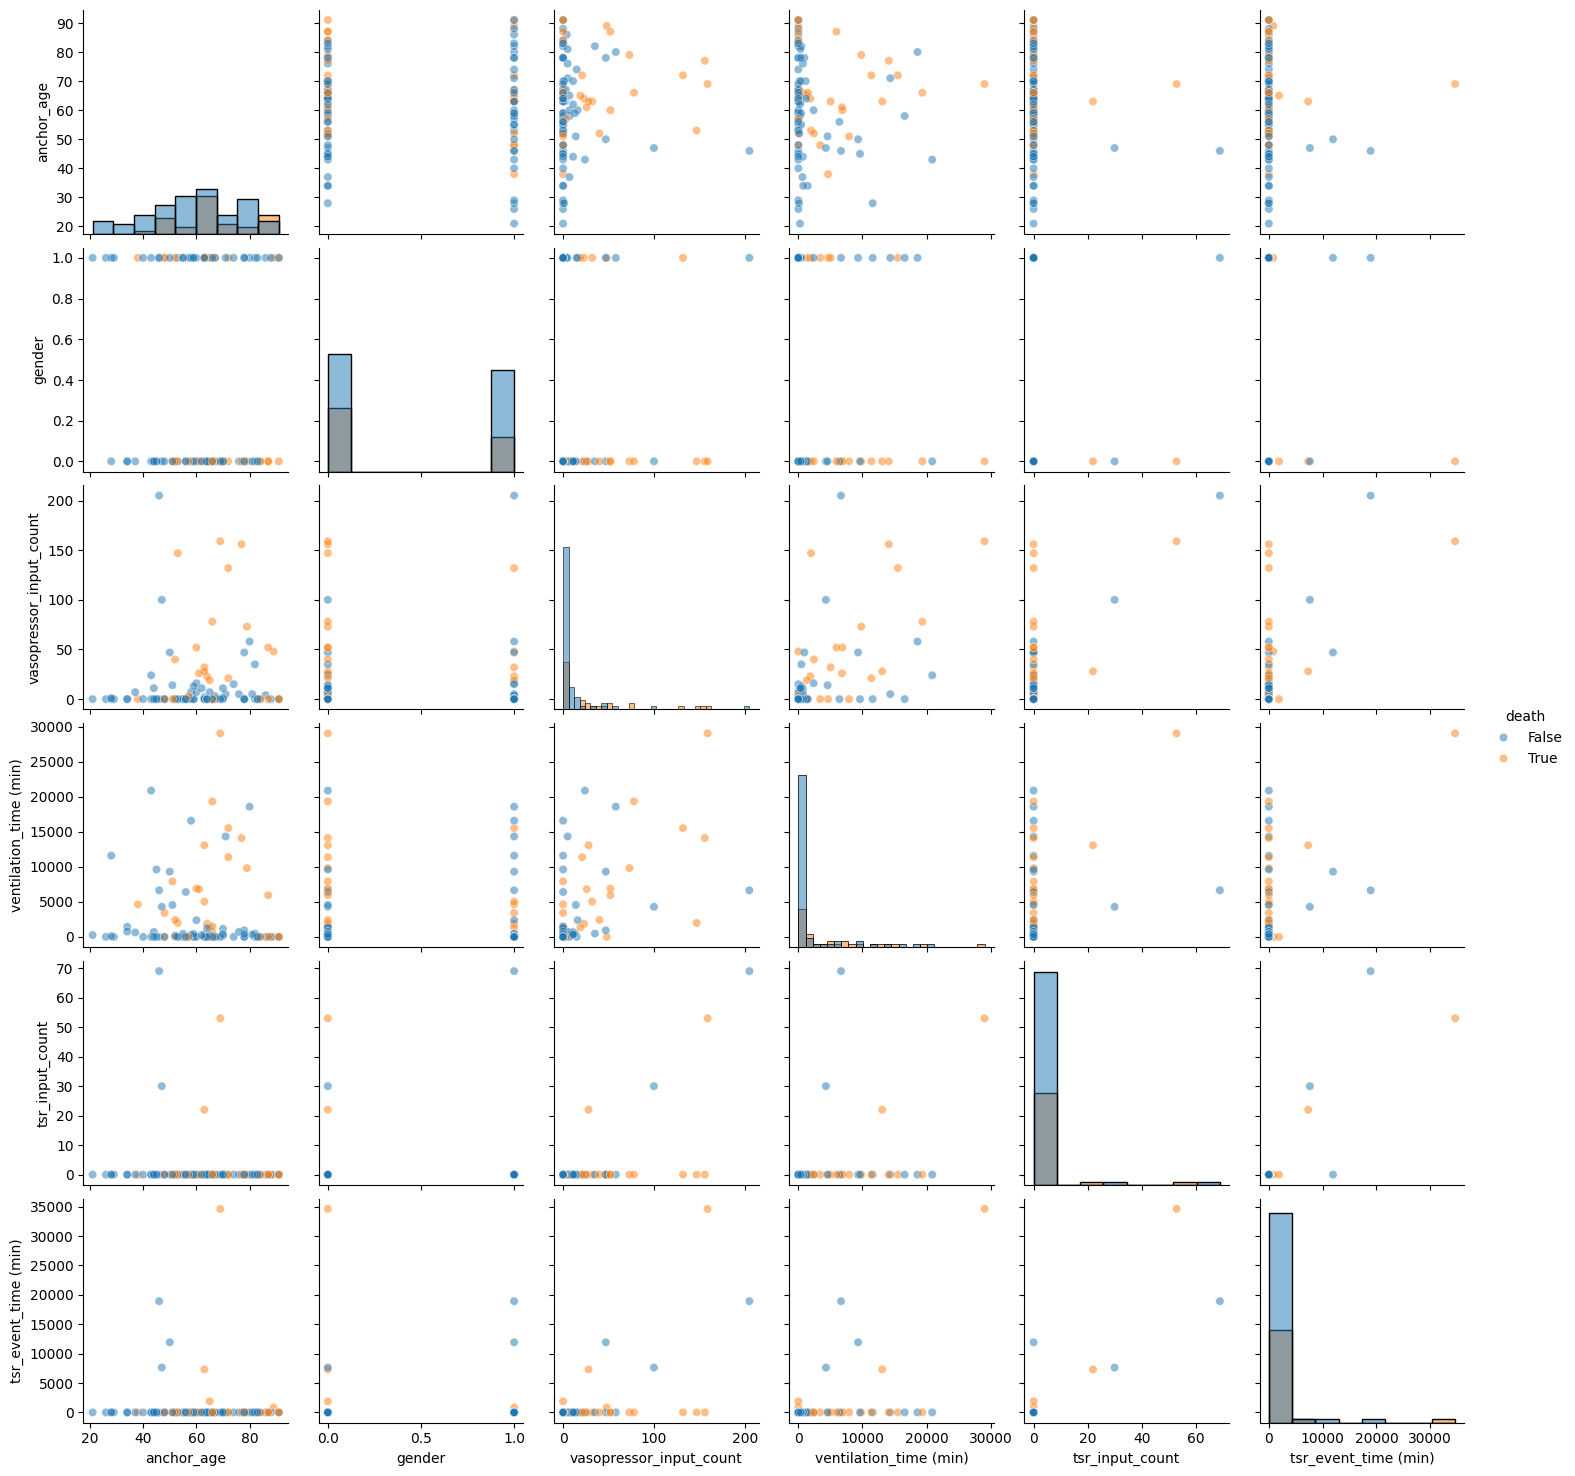

In [82]:
sns.pairplot(tabelona[['anchor_age','gender','vasopressor_input_count','ventilation_time (min)','tsr_input_count','tsr_event_time (min)','death']],hue='death',plot_kws={'alpha': 0.5},diag_kind="hist")

Text(0.5, 1.0, 'Morte x tempo de ventilação x contagem de vasopressores')

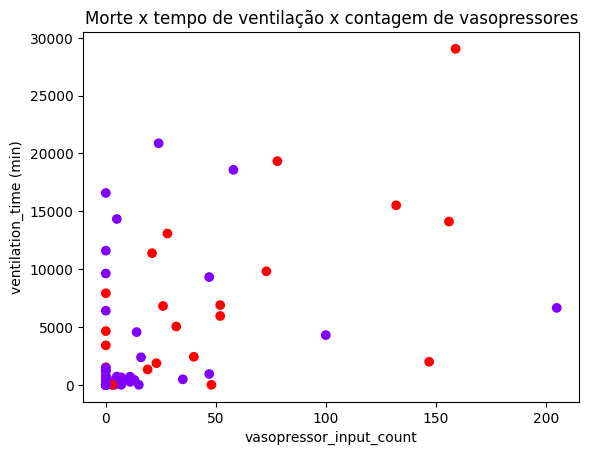

In [83]:
plt.scatter(tabelona['vasopressor_input_count'],tabelona['ventilation_time (min)'],c=tabelona['death'],cmap='rainbow')
plt.xlabel("vasopressor_input_count")
plt.ylabel("ventilation_time (min)")
plt.title("Morte x tempo de ventilação x contagem de vasopressores")

Criação das tabelas de comorbidades (baseado nos concepts, ou seja, os dados são de diagnostico)

In [84]:
import pandas as pd

# Carregar os dados (substitua pelos caminhos corretos dos arquivos CSV)
diagnoses_icd = pd.read_csv('hosp/diagnoses_icd.csv')
admissions = pd.read_csv('hosp/admissions.csv')

# Criar colunas icd9_code e icd10_code
diagnoses_icd['icd9_code'] = diagnoses_icd.apply(
    lambda row: row['icd_code'] if row['icd_version'] == 9 else None, axis=1
)
diagnoses_icd['icd10_code'] = diagnoses_icd.apply(
    lambda row: row['icd_code'] if row['icd_version'] == 10 else None, axis=1
)

# Função para verificar condições com base nos códigos ICD-9 e ICD-10
def check_condition(df, icd9_codes, icd10_codes, col_name):
    df[col_name] = df.apply(
        lambda row: 1 if (
            (row['icd9_code'] and any(row['icd9_code'].startswith(code) for code in icd9_codes)
            or (row['icd10_code'] and any(row['icd10_code'].startswith(code) for code in icd10_codes)
        ))) else 0, axis=1
    )
    return df

# Juntar as tabelas diagnoses_icd e admissions
merged_df = pd.merge(admissions, diagnoses_icd, on='hadm_id', how='left')

# Listas de códigos ICD-9 e ICD-10 para cada comorbidade
conditions = {
    'myocardial_infarct': {
        'icd9': ['410', '412'],
        'icd10': ['I21', 'I22', 'I252']
    },
    'congestive_heart_failure': {
        'icd9': ['428', '39891', '40201', '40211', '40291', '40401', '40403',
                 '40411', '40413', '40491', '40493', '4254', '4255', '4256',
                 '4257', '4258', '4259'],
        'icd10': ['I43', 'I50', 'I099', 'I110', 'I130', 'I132', 'I255', 'I420',
                  'I425', 'I426', 'I427', 'I428', 'I429', 'P290']
    },
    'Peripheral vascular disease':{
        'icd9' : ['440', '441','0930', '4373', '4471', '5571', '5579', 'V434','4431','4432','4433',
                  '4434','4435','4436','4437','4438','4439',],
        'icd10': ['I70', 'I71','I731', 'I738', 'I739', 'I771', 'I790', 'I792', 'K551', 'K558', 'K559', 'Z958', 'Z959']
    },
    'Cerebrovascular disease' :{
        'icd9':['430','431','432','433','434','435','436','437','438','439','36234','G45', 'G46'],
        'icd10': ['I60','I61','I62','I63','I64','I65','I66','I67','I68','I69','H340']
    },
    'Dementia':{
        'icd9':['290','2941', '3312'],
        'icd10': ['F051', 'G311','F00', 'F01', 'F02', 'F03', 'G30']
    },
    'Chronic pulmonary disease':{
        'icd9':['490','491','492','493','494','495','496','497','498','499','500','501','502','503','504','505','4168'
                , '4169', '5064', '5081', '5088'],
        'icd10':['J40','J41','J42','J43','J44','J45','J46','J47','J60','J61','J62','J63','J64','J65','J66','J67','I278',
                  'I279', 'J684', 'J701', 'J703']
    },
    'Rheumatic disease':{
        'icd9': ['725','4465', '7100', '7101', '7102', '7103', '7104', '7140', '7141', '7142', '7148'],
        'icd10': ['M05', 'M06', 'M32', 'M33', 'M34','M315', 'M351', 'M353', 'M360']
    },
    'Peptic ulcer disease': {
        'icd9': ['531', '532', '533', '534'],
        'icd10': ['K25', 'K26', 'K27', 'K28']
    },
    'Mild liver disease' :{
        'icd9': ['570', '571','0706', '0709', '5733', '5734', '5738', '5739', 'V427','07022', '07023', '07032', '07033', '07044', '07054'],
        'icd10': ['B18', 'K73', 'K74','K700', 'K701', 'K702', 'K703', 'K709', 'K713'
                  , 'K714', 'K715', 'K717', 'K760', 'K762'
                  , 'K763', 'K764', 'K768', 'K769', 'Z944']
    },
    'Diabetes without chronic complication' : {
        'icd9': ['2500', '2501', '2502', '2503', '2508', '2509'],
        'icd10': ['E100', 'E101', 'E106', 'E108', 'E109', 'E110', 'E111' , 'E116' , 'E118' , 'E119' , 'E120' , 'E121' , 'E126' , 'E128' ,
                   'E129' , 'E130' , 'E131' , 'E136' , 'E138' , 'E139' , 'E140' , 'E141', 'E146', 'E148', 'E149']
    },
    'Diabetes with chronic complication': {
        'icd9': ['2504', '2505', '2506', '2507'],
        'icd10' :['E102', 'E103', 'E104', 'E105', 'E107', 'E112', 'E113' , 'E114' , 'E115' , 'E117' , 'E122' , 'E123' , 'E124' , 'E125' ,
                   'E127' , 'E132' , 'E133' , 'E134' , 'E135' , 'E137' , 'E142' , 'E143', 'E144', 'E145', 'E147']
    },
    'Hemiplegia or paraplegia': {
        'icd9': ['342', '343','3341', '3440', '3441', '3442' , '3443', '3444', '3445', '3446', '3449'],
        'icd10': ['G81', 'G82','G041', 'G114', 'G801', 'G802', 'G830' , 'G831' , 'G832' , 'G833' , 'G834' , 'G839']
    },
    'Renal disease' :{
        'icd9': ['582', '585', '586', 'V56','5880', 'V420', 'V451','5830','5831','5832','5833','5834','5835','5836','5837','40301' , '40311' ,
                  '40391' , '40402' , '40403' , '40412' , '40413' , '40492' , '40493'],
        'icd10': ['N18', 'N19','I120', 'I131', 'N032', 'N033', 'N034' , 'N035' , 'N036' , 'N037' , 'N052' , 'N053' , 'N054' , 'N055' , 'N056' ,
                   'N057' , 'N250' , 'Z490' , 'Z491' , 'Z492' , 'Z940' , 'Z992']
    },
    'AIDS/HIV' :{
        'icd9': ['042', '043', '044'],
        'icd10':['B20', 'B21', 'B22', 'B24']
    },
    'Hypertension' : {
        'icd9':  ['4019', '5723'],
        'icd10': ['I2720', 'I272', 'K766', 'I10']
    },
    'Hypoglycemia':{
        'icd9': ['2511'],
        'icd10': ['E11649', 'E162']
    },
    'Hyperglycemia':{
        'icd9': [],
        'icd10': ['E0865', 'E1165']
    }
    ,
    'tabacco':{
        'icd9': ['3051', 'V1582'],
        'icd10': ['Z720']
    }
}

# Aplicar as condições para cada comorbidade
for condition, codes in conditions.items():
    merged_df = check_condition(merged_df, codes['icd9'], codes['icd10'], condition)

# Agrupar por hadm_id e calcular o máximo para cada comorbidade
comorbidities = merged_df.groupby('subject_id_x').agg({
    'myocardial_infarct': 'max',
    'congestive_heart_failure': 'max',
    'Peripheral vascular disease': 'max',
    'Cerebrovascular disease': 'max',
    'Dementia':'max',
    'Chronic pulmonary disease': 'max',
    'Diabetes with chronic complication': 'max',
    'Diabetes without chronic complication': 'max',
    'Rheumatic disease': 'max',
    'Peptic ulcer disease': 'max',
    'Mild liver disease': 'max',
    'Hemiplegia or paraplegia': 'max',
    'AIDS/HIV': 'max',
    'Renal disease': 'max',
    'Hypertension': 'max',
    'Hypoglycemia': 'max',
    'Hyperglycemia': 'max',
    'tabacco': 'max',
    # Adicione as outras colunas de comorbidades aqui...
}).reset_index()





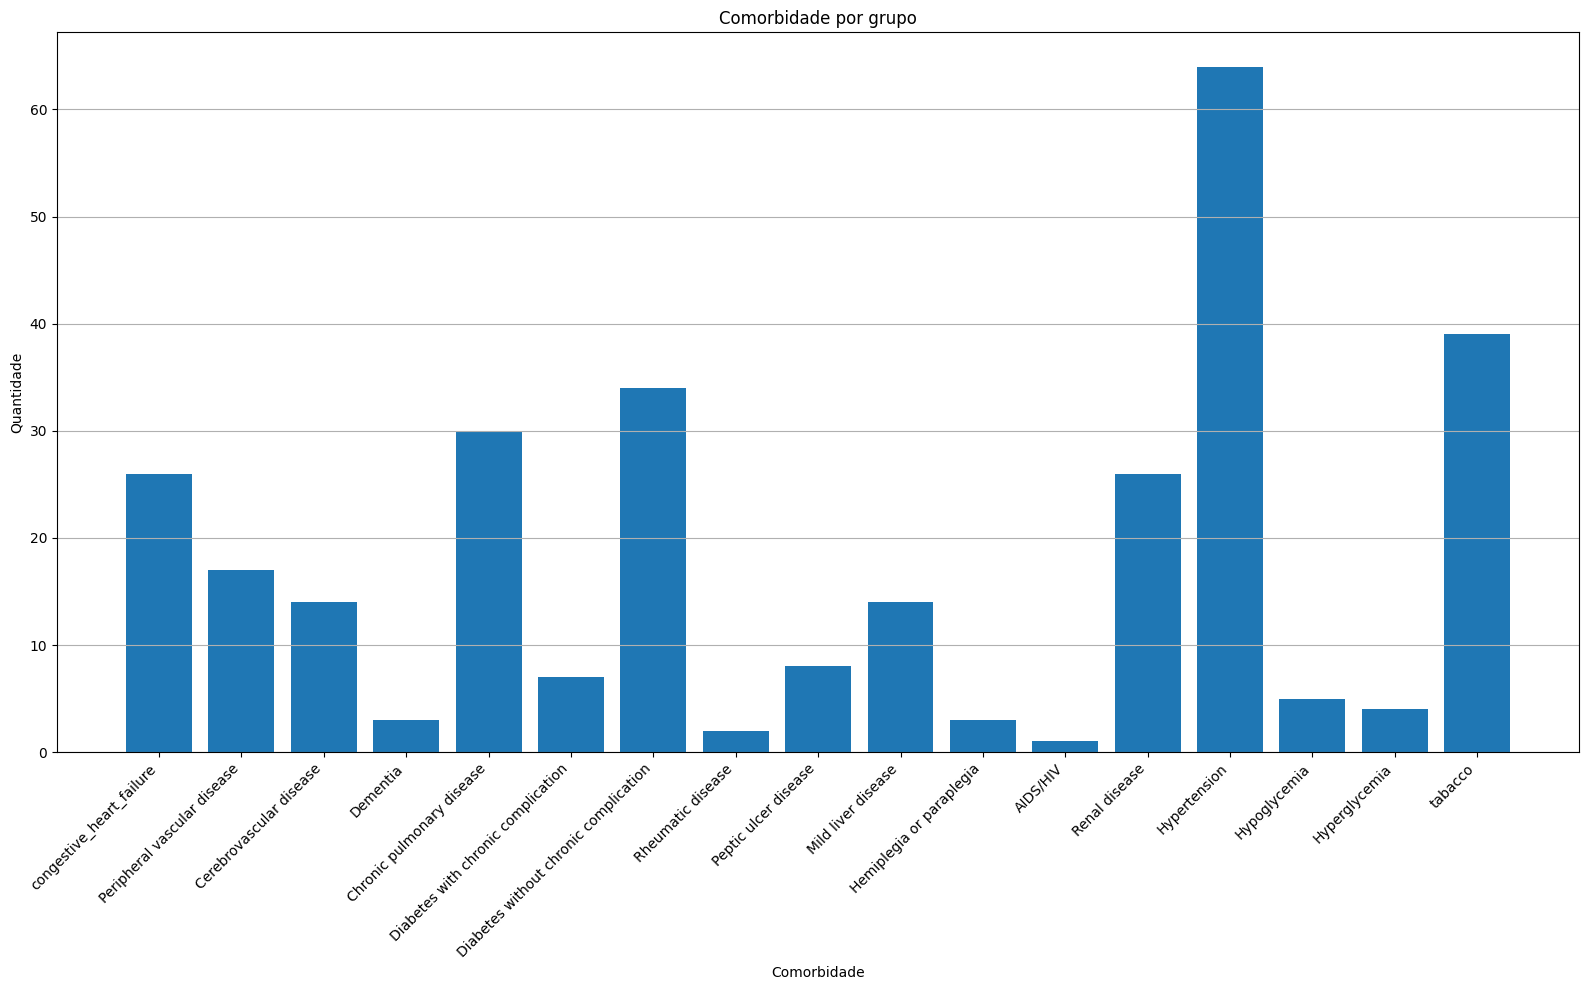

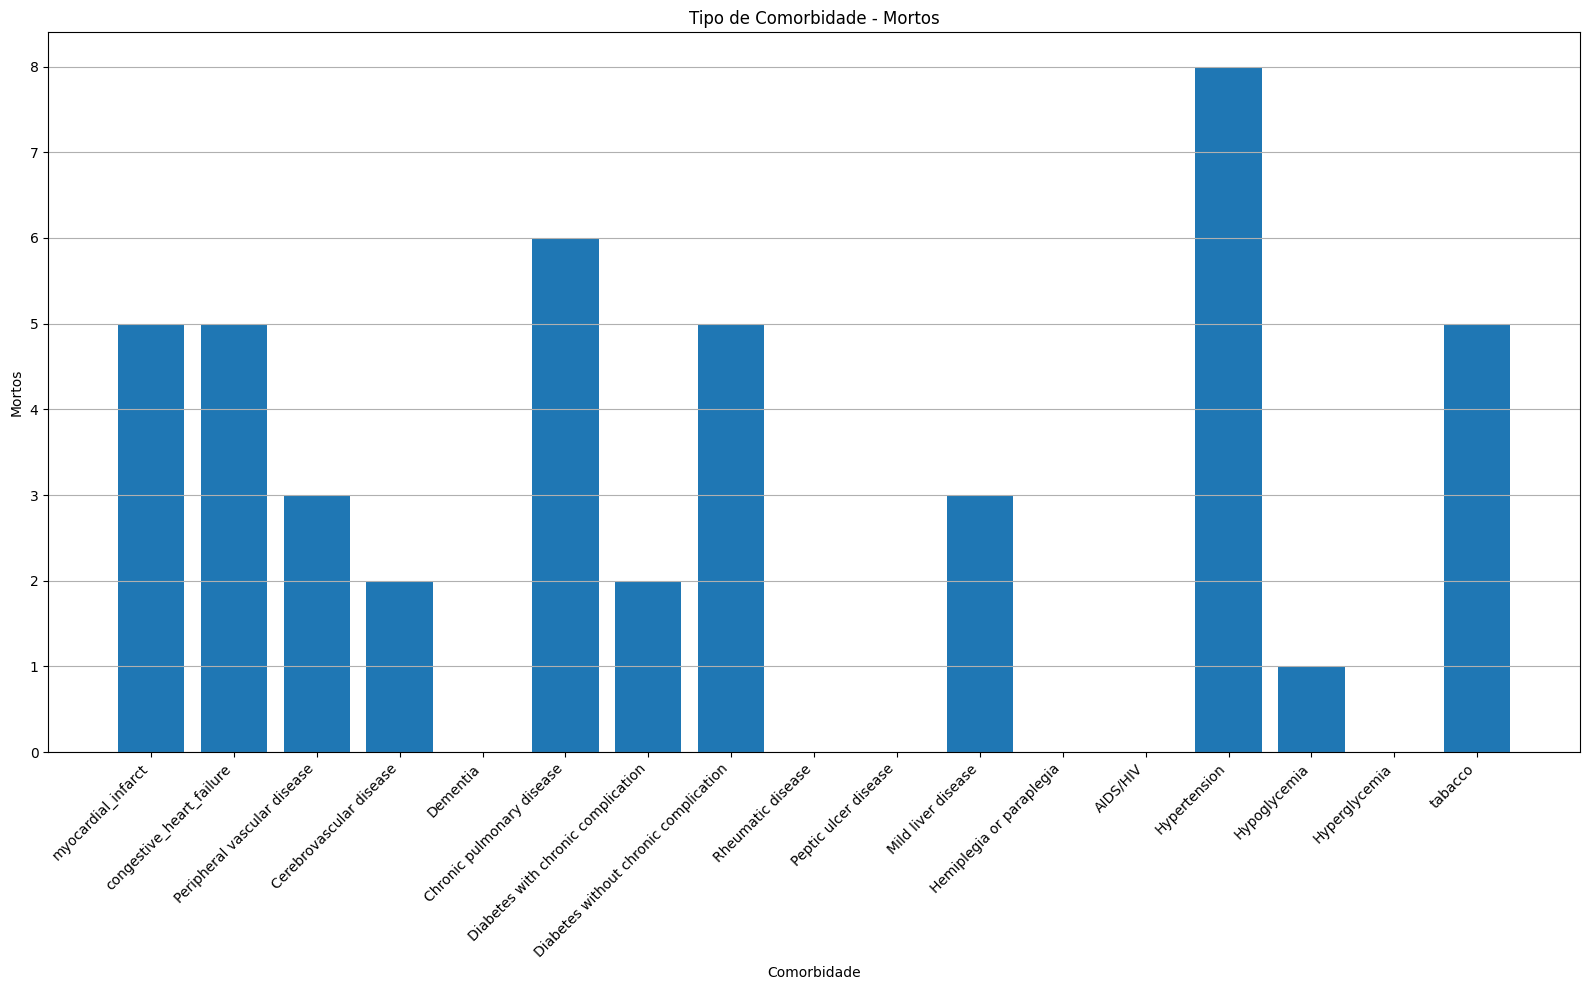

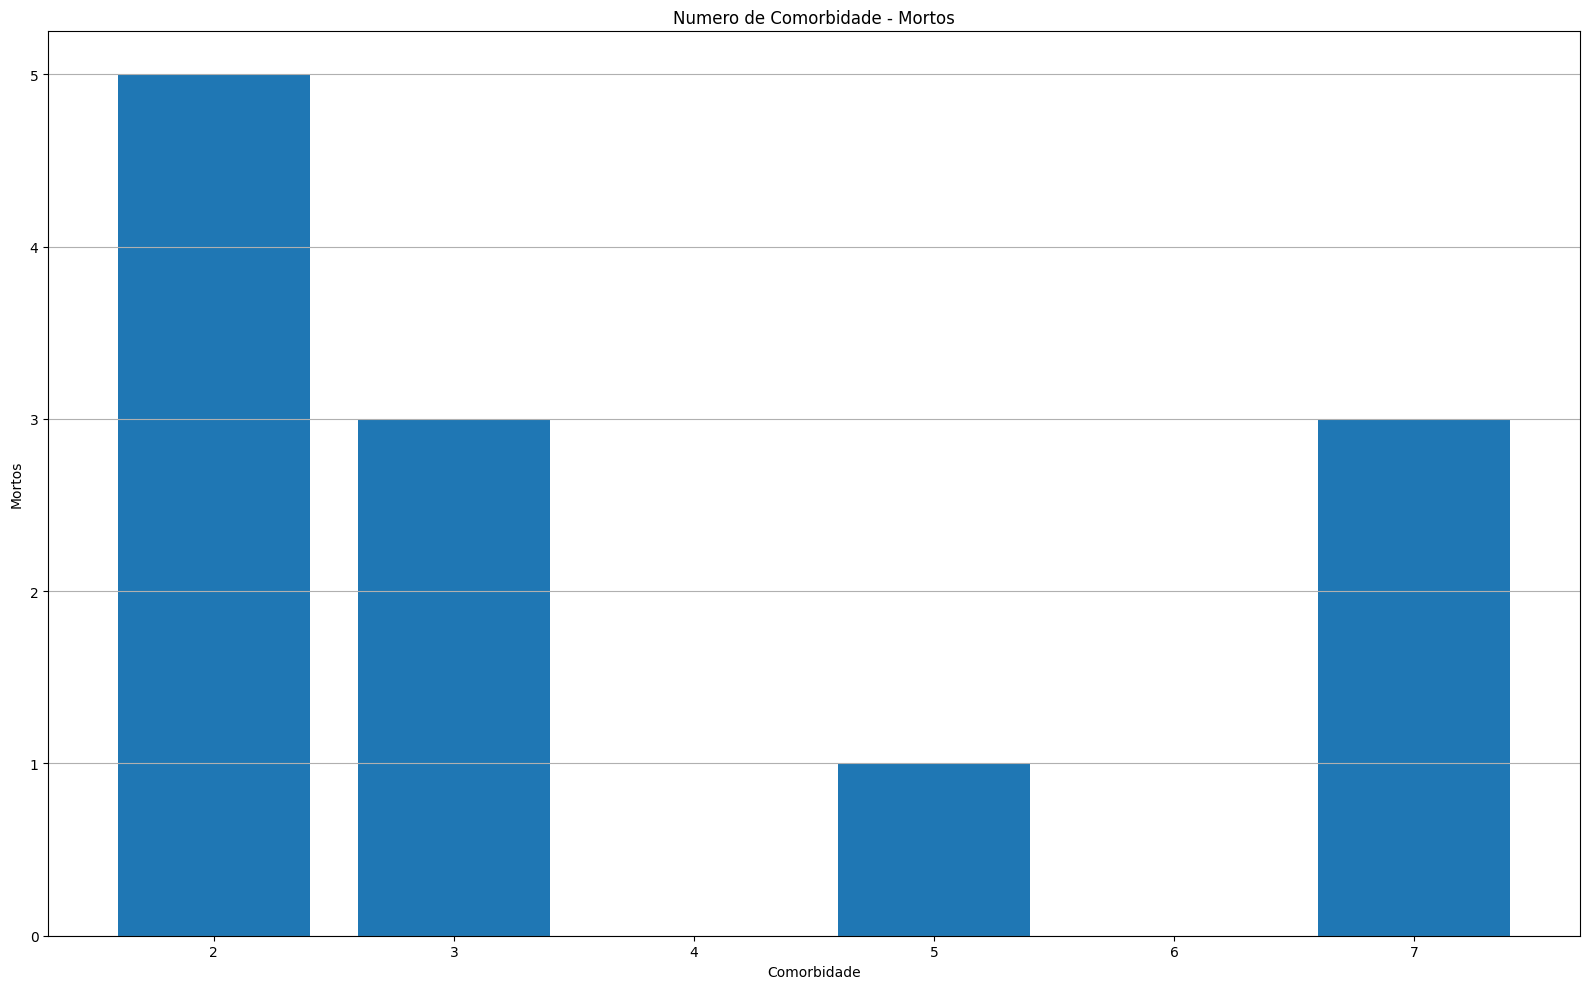

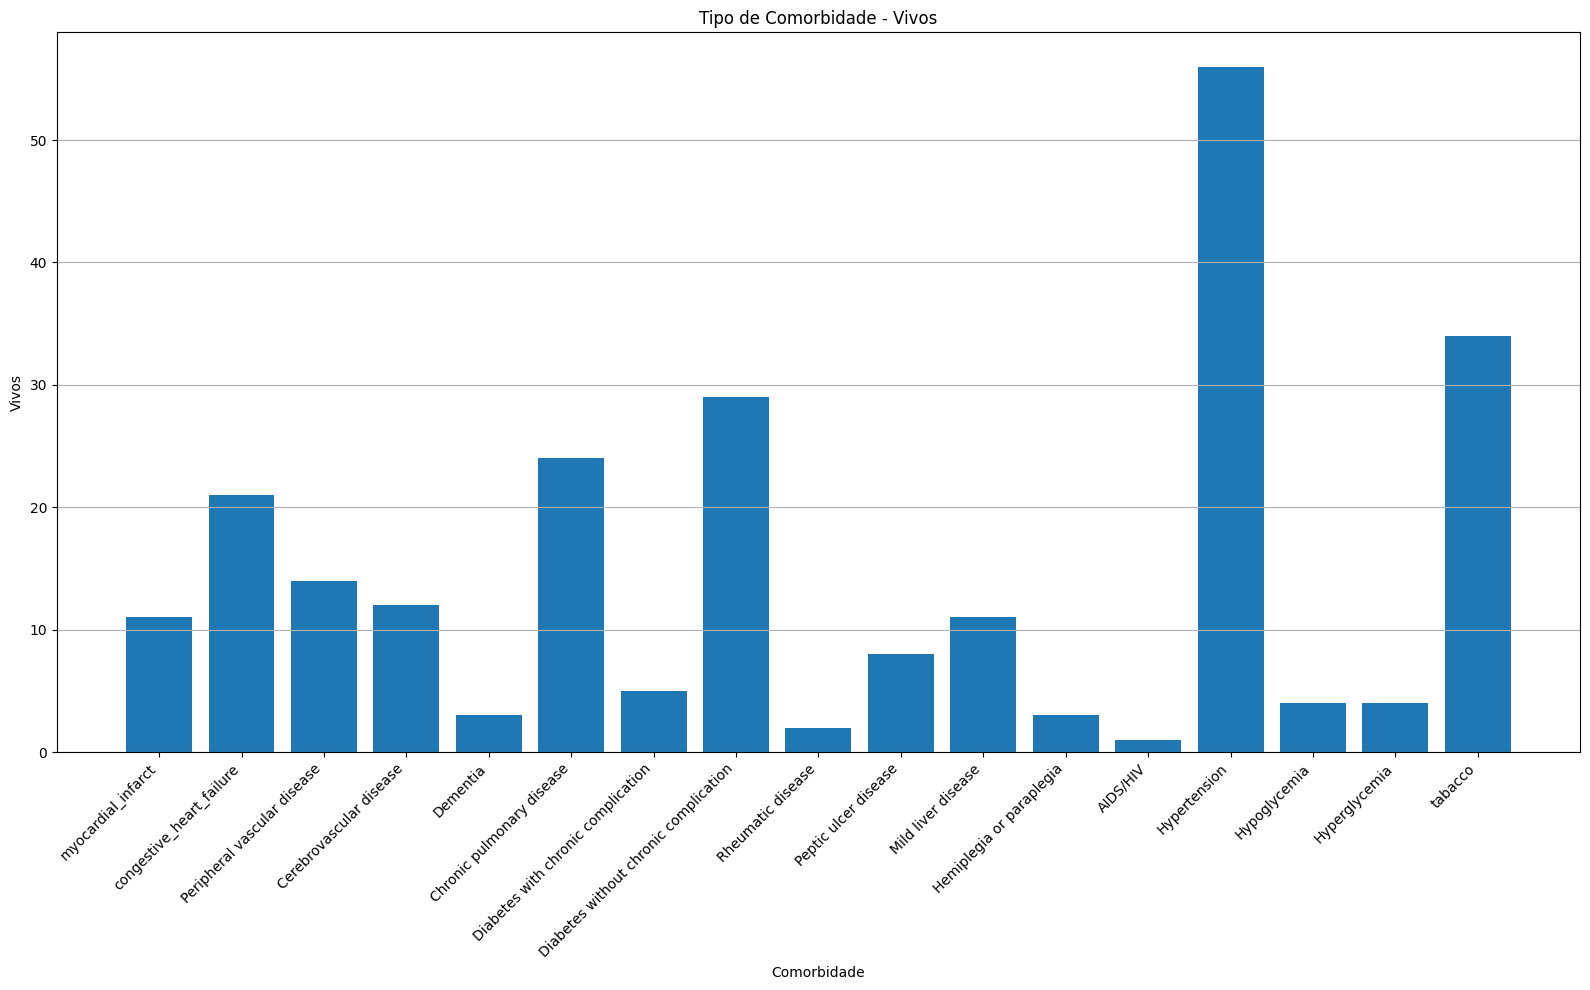

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


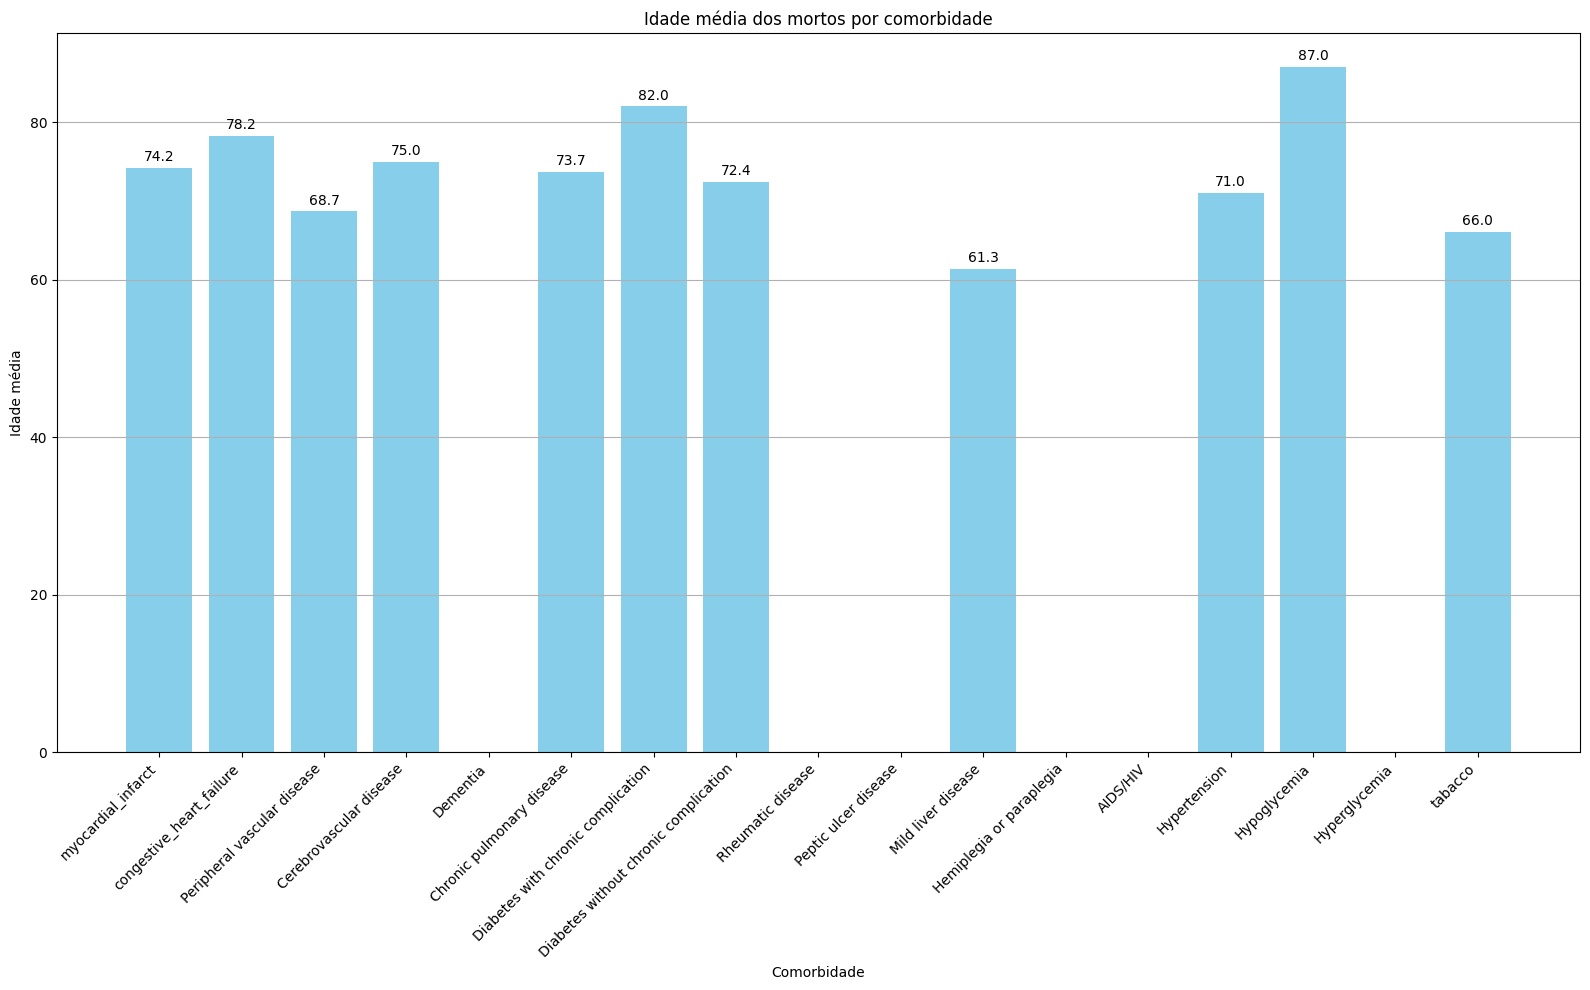

In [ ]:
comobirdade_sum = comorbidities.iloc[:,2:].sum()

plt.figure(figsize=(16,10))

plt.subplot(111)
plt.bar(comobirdade_sum.index,comobirdade_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Quantidade")
plt.title("Comorbidade por grupo")
plt.grid(axis='y')

plt.xticks(rotation=45, ha='right')

# Exibir o gráfico
plt.tight_layout()  # Ajusta o layout para evitar cortes
plt.show()



mortos = pd.merge(comorbidities,mortos_id,left_on='subject_id_x',right_on='subject_id',how='inner')

vivos = comorbidities[~comorbidities['subject_id_x'].isin(mortos['subject_id'])]


colunas_comorbidades = [
    'myocardial_infarct', 'congestive_heart_failure', 'Peripheral vascular disease',
    'Cerebrovascular disease', 'Dementia', 'Chronic pulmonary disease',
    'Diabetes with chronic complication', 'Diabetes without chronic complication',
    'Rheumatic disease', 'Peptic ulcer disease', 'Mild liver disease',
    'Hemiplegia or paraplegia', 'AIDS/HIV', 'Hypertension', 'Hypoglycemia',
    'Hyperglycemia', 'tabacco'
]

# Filtra as colunas de comorbidades e soma os valores
mortos_sum = mortos[colunas_comorbidades].sum()
mortos_sum1 = mortos[colunas_comorbidades].sum(axis=1)

max_comorbidades_por_paciente = mortos_sum1.max()

contagem_mortos_por_comorbidades = mortos_sum1.value_counts().sort_index()

vivos_sum = vivos[colunas_comorbidades].sum()


plt.figure(figsize=(16,10))
plt.subplot(111)
plt.bar(mortos_sum.index, mortos_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Mortos")
plt.title("Tipo de Comorbidade - Mortos")
plt.grid(axis='y')

plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

plt.figure(figsize=(16,10))
plt.subplot(111)
plt.bar(contagem_mortos_por_comorbidades.index, contagem_mortos_por_comorbidades.values)
plt.xlabel("Comorbidade")
plt.ylabel("Mortos")
plt.title("Numero de Comorbidade - Mortos")
plt.grid(axis='y')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

plt.figure(figsize=(16,10))
plt.subplot(111)
plt.bar(vivos_sum.index, vivos_sum.values)
plt.xlabel("Comorbidade")
plt.ylabel("Vivos")
plt.title("Tipo de Comorbidade - Vivos")
plt.grid(axis='y')

plt.xticks(rotation=45,ha='right')

plt.tight_layout()
plt.show()

mortos_idade = pd.merge(tabelona, mortos, left_on='subject_id',right_on='subject_id_x',how='left')

# Dicionário para armazenar as médias de idade por comorbidade
medias_por_comorbidade = {}

# Calcular a média de idade para cada comorbidade
for comorbidade in colunas_comorbidades:
    media_idade = mortos_idade[mortos_idade[comorbidade] == 1]['anchor_age'].mean()
    medias_por_comorbidade[comorbidade] = media_idade

# Converter o dicionário em um DataFrame para facilitar a plotagem
df_medias = pd.DataFrame(list(medias_por_comorbidade.items()), columns=['Comorbidade', 'Idade Média'])

# Plotagem do gráfico de barras
plt.figure(figsize=(16, 10))
bars = plt.bar(df_medias['Comorbidade'], df_medias['Idade Média'], color='skyblue')
plt.xlabel("Comorbidade")
plt.ylabel("Idade média")
plt.title("Idade média dos mortos por comorbidade")
plt.grid(axis='y')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Posição x do texto (centro da barra)
        height + 0.5,  # Posição y do texto (ligeiramente acima da barra)
        f'{height:.1f}',  # Valor formatado com 1 casa decimal
        ha='center',  # Alinhamento horizontal centralizado
        va='bottom',  # Alinhamento vertical na base
        fontsize=10
    )
# Rotação dos rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajuste do layout para evitar cortes nos rótulos
plt.tight_layout()

# Exibir o gráfico
plt.show()


/tmp/ipykernel_327454/3023408382.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  tempo_por_comorbidade = pd.concat([tempo_por_comorbidade, novo_dado], ignore_index=True)


                              Comorbidade  Tempo_Ventilacao
0                      myocardial_infarct           41820.0
1                congestive_heart_failure           54918.0
2             Peripheral vascular disease           38488.0
3                 Cerebrovascular disease             719.0
4                                Dementia               0.0
5               Chronic pulmonary disease           51325.0
6      Diabetes with chronic complication           20063.0
7   Diabetes without chronic complication           73489.0
8                       Rheumatic disease               0.0
9                    Peptic ulcer disease               0.0
10                     Mild liver disease           36511.0
11               Hemiplegia or paraplegia               0.0
12                               AIDS/HIV               0.0
13                           Hypertension           82425.0
14                           Hypoglycemia            5950.0
15                          Hyperglycemi

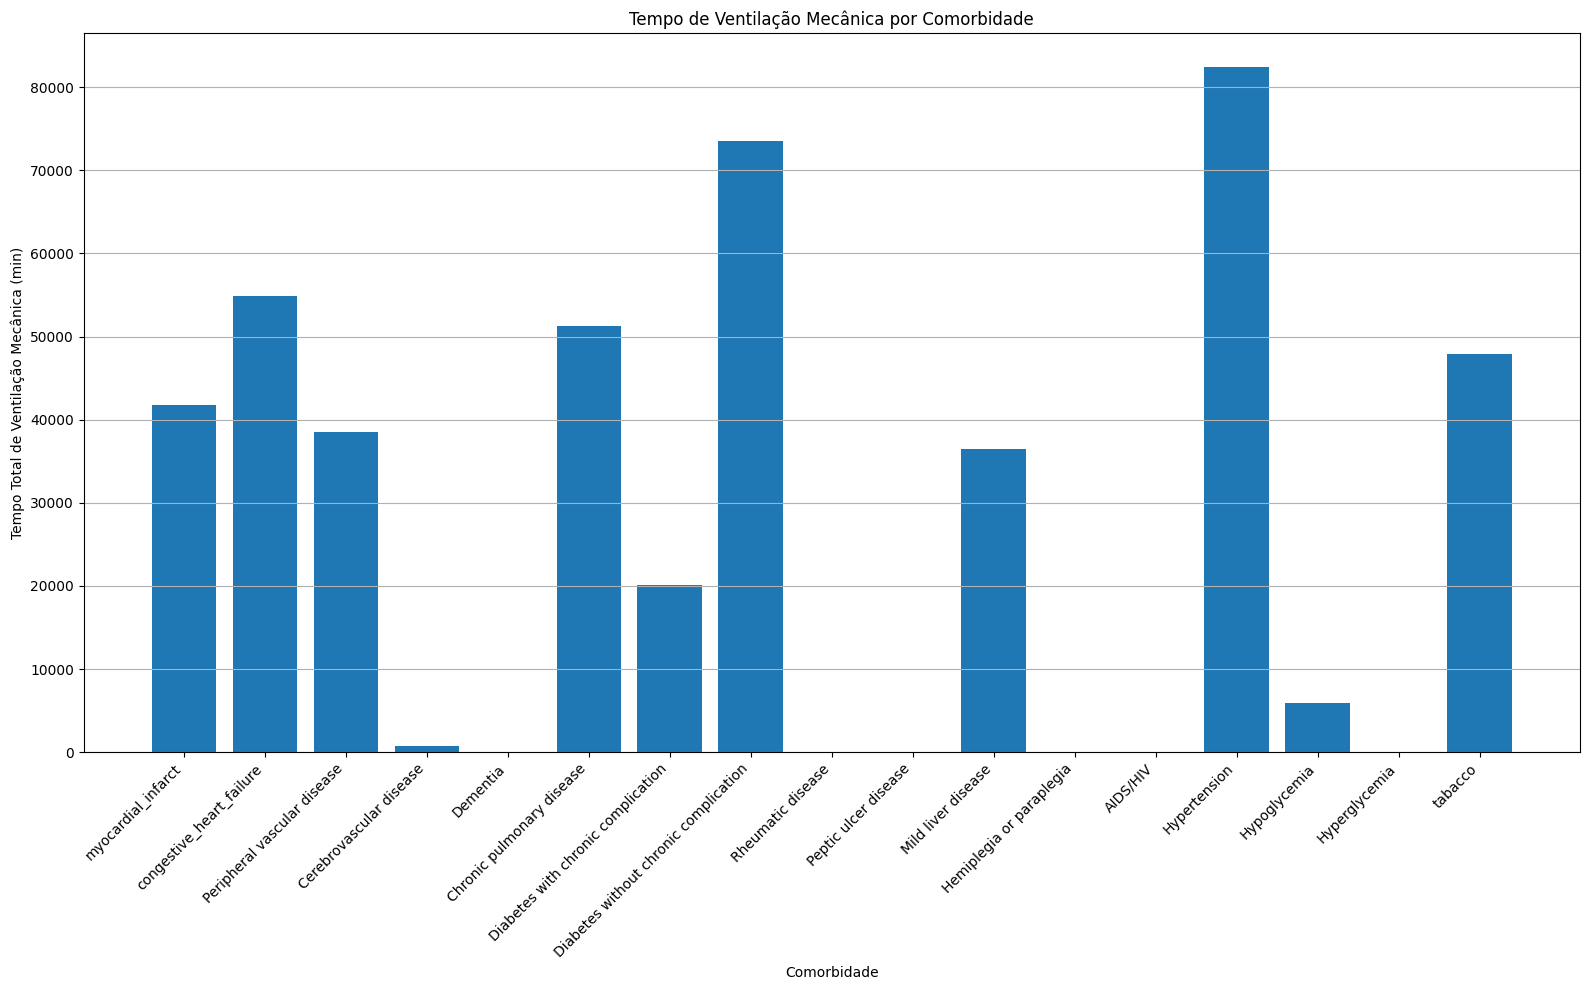

/tmp/ipykernel_327454/3023408382.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dose_por_comorbidade = pd.concat([dose_por_comorbidade, novo_dado], ignore_index=True)


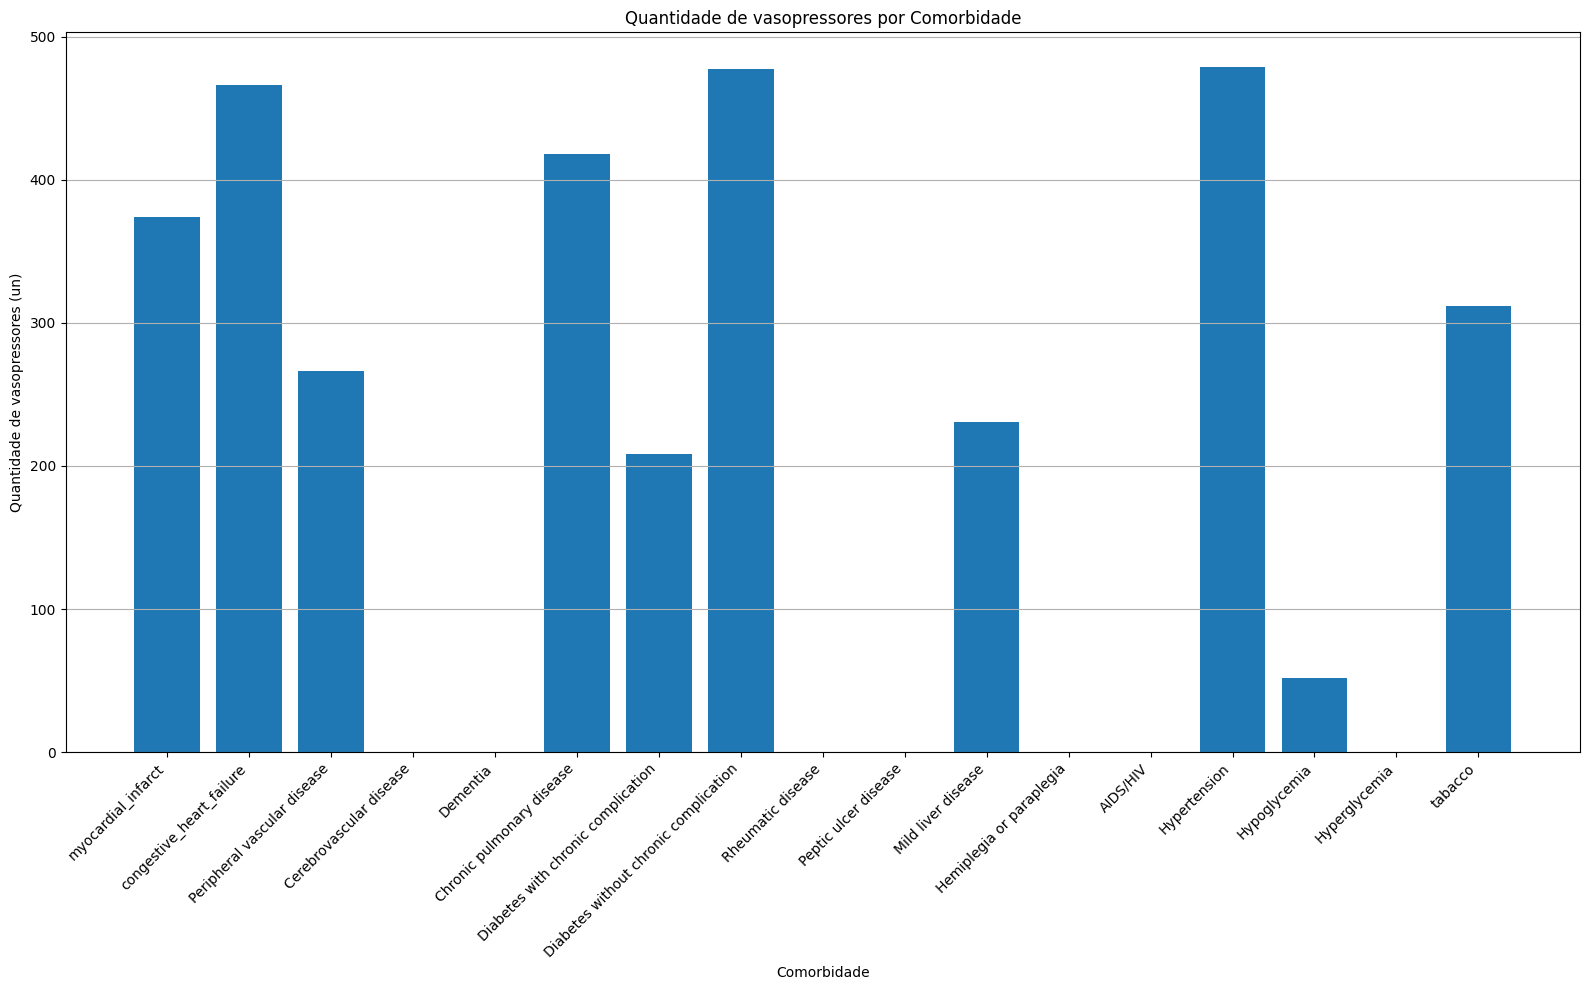

In [ ]:
mortos_total = pd.merge(tabelona,mortos,left_on='subject_id',right_on='subject_id',how='left')

tempo_por_comorbidade = pd.DataFrame(columns=['Comorbidade', 'Tempo_Ventilacao'])

# Itera sobre cada comorbidade e calcula o tempo total de ventilação mecânica
for comorbidade in colunas_comorbidades:
    tempo_total = mortos_total[mortos_total[comorbidade] == 1]['ventilation_time (min)'].sum()
    novo_dado = pd.DataFrame({
        'Comorbidade': [comorbidade],
        'Tempo_Ventilacao': [tempo_total]
    })
    tempo_por_comorbidade = pd.concat([tempo_por_comorbidade, novo_dado], ignore_index=True)

# Cria o gráfico de barras
plt.figure(figsize=(16, 10))
plt.bar(tempo_por_comorbidade['Comorbidade'], tempo_por_comorbidade['Tempo_Ventilacao'])
plt.xlabel("Comorbidade")
plt.ylabel("Tempo Total de Ventilação Mecânica (min)")
plt.title("Tempo de Ventilação Mecânica por Comorbidade")
plt.grid(axis='y')

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()


dose_por_comorbidade = pd.DataFrame(columns=['Comorbidade', 'qtd_vasopressor'])

# Itera sobre cada comorbidade e calcula o tempo total de ventilação mecânica
for comorbidade in colunas_comorbidades:
    qtd_total = mortos_total[mortos_total[comorbidade] == 1]['vasopressor_input_count'].sum()
    novo_dado = pd.DataFrame({
        'Comorbidade': [comorbidade],
        'qtd_vasopressor': [qtd_total]
    })
    dose_por_comorbidade = pd.concat([dose_por_comorbidade, novo_dado], ignore_index=True)


# Cria o gráfico de barras
plt.figure(figsize=(16, 10))
plt.bar(dose_por_comorbidade['Comorbidade'], dose_por_comorbidade['qtd_vasopressor'])
plt.xlabel("Comorbidade")
plt.ylabel("Quantidade de vasopressores (un)")
plt.title("Quantidade de vasopressores por Comorbidade")
plt.grid(axis='y')

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45, ha='right')

# Ajusta o layout e exibe o gráfico
plt.tight_layout()
plt.show()

